# Phishing Domain Detection: Feature Engineering and XGBoost Modeling

This notebook demonstrates the process of building a phishing domain detection model using XGBoost. It covers data loading, feature engineering, class balancing, model training with sample weighting, and evaluation, with a focus on influencing feature importance for specific domain characteristics.

In [49]:
import pandas as pd
from urllib.parse import urlparse

# ==================================================
# DOMAIN EXTRACTION
# ==================================================

def extract_domain(url):
    try:
        domain = urlparse(url).netloc.lower()

        if domain.startswith("www."):
            domain = domain[4:]

        return domain

    except:
        return None



# ==================================================
# PHISHTANK
# ==================================================

phishtank = pd.read_csv("verified_online.csv")

phishtank["domain"] = (
    phishtank["url"]
    .astype(str)
    .apply(extract_domain)
)

phishtank["label"] = "phishing"

phishtank = phishtank[
    ["domain", "label"]
]


# ==================================================
# TRANCO
# ==================================================

tranco = pd.read_csv(
    "top-1m.csv",
    header=None,
    names=["rank", "domain"]
)

# top 20k domains
tranco = tranco.head(36000)

tranco["label"] = "legitimate"

tranco = tranco[
    ["domain", "label"]
]


# ==================================================
# ADD LEGITIMATE SUBDOMAINS
# ==================================================

legit_subdomains = [
    "mail.google.com",
    "drive.google.com",
    "accounts.google.com",
    "docs.google.com",
    "maps.google.com",

    "login.microsoftonline.com",
    "outlook.office365.com",
    "portal.office.com",

    "aws.amazon.com",
    "console.aws.amazon.com",

    "business.facebook.com",
    "developers.facebook.com",

    "support.apple.com",
    "id.apple.com",

    "mail.yahoo.com",
    "finance.yahoo.com",

    "login.live.com",
    "account.live.com",

    "mail.proton.me",
    "calendar.google.com",

    "web.whatsapp.com",
    "business.whatsapp.com"
]

subdomain_df = pd.DataFrame({
    "domain": legit_subdomains,
    "label": "legitimate"
})


# ==================================================
# COMBINE
# ==================================================

combined = pd.concat(
    [
        phishtank,
        tranco,
        subdomain_df
    ],
    ignore_index=True
)

combined.dropna(inplace=True)

combined["domain"] = (
    combined["domain"]
    .astype(str)
    .str.strip()
    .str.lower()
)

combined.drop_duplicates(
    subset=["domain"],
    inplace=True
)

combined = combined[
    combined["domain"].str.len() > 0
]

# ==================================================
# SAVE
# ==================================================

print("\nClass Distribution:")
print(
    combined["label"]
    .value_counts()
)

print(
    "\nUnique Domains:",
    len(combined)
)

combined.to_csv(
    "combined_domains.csv",
    index=False
)

print(
    "\nSaved combined_domains.csv"
)


Class Distribution:
label
legitimate    35899
phishing      32563
Name: count, dtype: int64

Unique Domains: 68462

Saved combined_domains.csv


## 1. Initial Data Loading and Combination

This section loads and combines data from PhishTank (phishing domains) and Tranco (legitimate domains). It also adds a small set of known legitimate subdomains to enhance the dataset. The combined dataset is then cleaned, deduplicated, and saved for further feature engineering.

In [50]:
!pip install pandas numpy python-Levenshtein tldextract

## 2. Install Required Libraries

This cell ensures all necessary Python libraries for data manipulation, string operations, and TLD extraction are installed and available in the environment.

In [51]:
import pandas as pd
import numpy as np
import math
import ipaddress
import tldextract
from Levenshtein import distance

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv("combined_domains.csv")

# ==================================================
# KNOWN BRANDS
# ==================================================

BRANDS = [
    "google",
    "facebook",
    "amazon",
    "paypal",
    "microsoft",
    "apple",
    "instagram",
    "netflix",
    "linkedin",
    "twitter",
    "sbi",
    "hdfc",
    "icici",
    "axis",
    "uidai",
    "epfo"
]

KNOWN_ROOTS = {
    "google.com",
    "facebook.com",
    "amazon.com",
    "paypal.com",
    "microsoft.com",
    "apple.com",
    "instagram.com"
}

KEYWORDS = [
    "login",
    "secure",
    "verify",
    "account",
    "update",
    "signin",
    "support",
    "payment"
]

# ==================================================
# ENTROPY
# ==================================================

def entropy(domain):

    probs = [
        float(domain.count(c)) / len(domain)
        for c in set(domain)
    ]

    return -sum(
        p * math.log2(p)
        for p in probs
    )

# ==================================================
# IP DETECTION
# ==================================================

def is_ip(domain):

    try:
        ipaddress.ip_address(domain)
        return 1

    except:
        return 0

# ==================================================
# LEVENSHTEIN DISTANCE
# ==================================================

def min_brand_distance(domain):

    ext = tldextract.extract(domain)

    name = ext.domain.lower()

    distances = [
        distance(name, brand)
        for brand in BRANDS
    ]

    return min(distances)

# ==================================================
# KNOWN ROOT DOMAIN
# ==================================================

def known_brand_root(domain):

    ext = tldextract.extract(domain)

    root = f"{ext.domain}.{ext.suffix}"

    return int(root in KNOWN_ROOTS)

# ==================================================
# FEATURE EXTRACTION
# ==================================================

def extract_features(domain):

    ext = tldextract.extract(domain)

    suffix = ext.suffix

    parts = domain.split(".")

    domain_depth = max(
        len(parts) - 2,
        0
    )

    unicode_count = sum(
        ord(c) > 127
        for c in domain
    )

    return {

        # --------------------------------------
        # STRUCTURE FEATURES
        # --------------------------------------

        "length":
            len(domain),

        "subdomain_count":
            domain_depth,

        "domain_depth":
            domain_depth,

        "hyphen_count":
            domain.count("-"),

        "digit_count":
            sum(
                c.isdigit()
                for c in domain
            ),

        "special_char_count":
            sum(
                not c.isalnum() and c != "."
                for c in domain
            ),

        "entropy":
            entropy(domain),

        "is_ip_address":
            is_ip(domain),

        # --------------------------------------
        # LEXICAL FEATURES
        # --------------------------------------

        "has_login":
            int("login" in domain),

        "has_secure":
            int("secure" in domain),

        "has_verify":
            int("verify" in domain),

        "has_account":
            int("account" in domain),

        "has_update":
            int("update" in domain),

        "has_signin":
            int("signin" in domain),

        "has_support":
            int("support" in domain),

        "has_payment":
            int("payment" in domain),

        "brand_match":
            int(
                any(
                    brand in domain
                    for brand in BRANDS
                )
            ),

        "known_brand_root":
            known_brand_root(domain),

        "min_brand_distance":
            min_brand_distance(domain),

        # --------------------------------------
        # IDN FEATURES
        # --------------------------------------

        "has_punycode":
            int("xn--" in domain),

        "contains_unicode":
            int(unicode_count > 0),

        "unicode_ratio":
            unicode_count / max(len(domain), 1),

        # --------------------------------------
        # TLD
        # --------------------------------------

        "tld":
            suffix
    }

# ==================================================
# APPLY FEATURES
# ==================================================

features = df["domain"].apply(
    extract_features
)

feature_df = pd.DataFrame(
    features.tolist()
)

final_df = pd.concat(
    [df, feature_df],
    axis=1
)

print(final_df.head())

print("\nShape:", final_df.shape)

final_df.to_csv(
    "domain_features_v2.csv",
    index=False
)

print(
    "\nSaved domain_features_v2.csv"
)

                                     domain     label  length  \
0             allegrolokalnie.pl-676767.sbs  phishing      29   
1                     clee-reactivation.com  phishing      21   
2            prime.gestion-souscription.com  phishing      30   
3  klelnanzeigen-deutsch.srvc-de834294.info  phishing      40   
4                                brtzxv.sbs  phishing      10   

   subdomain_count  domain_depth  hyphen_count  digit_count  \
0                1             1             1            6   
1                0             0             1            0   
2                1             1             1            0   
3                1             1             2            6   
4                0             0             0            0   

   special_char_count   entropy  is_ip_address  ...  has_signin  has_support  \
0                   1  3.784898              0  ...           0            0   
1                   1  3.558519              0  ...           0       

In [52]:
COMMON_TLDS = {
    "com","org","net","gov","edu"
}

SUSPICIOUS_TLDS = {
    "xyz","top","cc","cam","cyou","shop"
}

final_df["is_common_tld"] = (
    final_df["tld"].isin(COMMON_TLDS)
).astype(int)

final_df["is_suspicious_tld"] = (
    final_df["tld"].isin(SUSPICIOUS_TLDS)
).astype(int)

final_df.drop(
    columns=["tld"],
    inplace=True
)

In [53]:
import pandas as pd
import numpy as np
import math
import tldextract
from Levenshtein import distance

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("combined_domains.csv")

# ==========================================
# KNOWN BRANDS / CSE DOMAINS
# ==========================================

KNOWN_BRANDS = [
    "google",
    "facebook",
    "amazon",
    "paypal",
    "microsoft",
    "apple",
    "instagram",
    "netflix",
    "linkedin",
    "twitter",
    "sbi",
    "hdfc",
    "icici",
    "axis",
    "uidai",
    "epfo",
    "gov"
]

KNOWN_ROOTS = {
    "google.com",
    "facebook.com",
    "amazon.com",
    "paypal.com",
    "microsoft.com",
    "apple.com",
    "instagram.com"
}

KEYWORDS = [
    "login",
    "secure",
    "verify",
    "account",
    "update",
    "signin",
    "support",
    "banking",
    "payment"
]

COMMON_TLDS = {
    "com",
    "org",
    "net",
    "edu",
    "gov",
    "mil",
    "int"
}

COUNTRY_CODE_TLDS = {
    "in", "us", "uk", "au", "ca", "de", "fr",
    "jp", "cn", "sg", "ae", "ru", "br",
    "it", "es", "nl", "ch", "se", "no",
    "fi", "za", "kr"
}

HIGH_RISK_TLDS = {
    "xyz",
    "top",
    "click",
    "work",
    "gq",
    "ml",
    "cf",
    "tk",
    "ga",
    "pw",
    "buzz",
    "cam",
    "cyou",
    "icu",
    "monster",
    "rest",
    "fit",
    "accountant",
    "science",
    "support",
    "review",
    "country",
    "kim",
    "party",
    "trade",
    "stream",
    "download",
    "racing",
    "win",
    "loan",
    "men",
    "date",
    "faith",
    "cricket",
    "zip",
    "mov"
}

# ==========================================
# ENTROPY
# ==========================================

def entropy(domain):

    probs = [
        float(domain.count(c)) / len(domain)
        for c in set(domain)
    ]

    return -sum(
        p * math.log2(p)
        for p in probs
    )

# ==========================================
# LEVENSHTEIN
# ==========================================

def min_brand_distance(domain):

    ext = tldextract.extract(domain)

    name = ext.domain.lower()

    distances = [
        distance(name, brand)
        for brand in KNOWN_BRANDS
    ]

    return min(distances)

# ==========================================
# BRAND ROOT
# ==========================================

def known_brand_root(domain):

    ext = tldextract.extract(domain)

    root = f"{ext.domain}.{ext.suffix}"

    return int(root in KNOWN_ROOTS)

# ==========================================
# FEATURE EXTRACTION
# ==========================================

def extract_features(domain):

    ext = tldextract.extract(domain)

    root = ext.domain

    suffix = ext.suffix

    subdomain = ext.subdomain

    full_root = f"{root}.{suffix}"

    domain_parts = domain.split(".")

    # domain depth
    domain_depth = max(len(domain_parts) - 2, 0)

    # unicode
    unicode_count = sum(
        ord(c) > 127
        for c in domain
    )

    return {

        # ----------------------------------
        # STRUCTURE
        # ----------------------------------

        "length":
            len(domain),

        "subdomain_count":
            domain_depth,

        "domain_depth":
            domain_depth,

        "hyphen_count":
            domain.count("-"),

        "digit_count":
            sum(
                c.isdigit()
                for c in domain
            ),

        "special_char_count":
            sum(
                not c.isalnum() and c != "."
                for c in domain
            ),

        "entropy":
            entropy(domain),

        # ----------------------------------
        # LEXICAL
        # ----------------------------------

        "has_login":
            int("login" in domain),

        "has_secure":
            int("secure" in domain),

        "has_verify":
            int("verify" in domain),

        "has_account":
            int("account" in domain),

        "has_update":
            int("update" in domain),

        "has_signin":
            int("signin" in domain),

        "has_support":
            int("support" in domain),

        "has_payment":
            int("payment" in domain),

        "brand_match":
            int(
                any(
                    brand in domain
                    for brand in KNOWN_BRANDS
                )
            ),

        "known_brand_root":
            known_brand_root(domain),

        "min_brand_distance":
            min_brand_distance(domain),

        # ----------------------------------
        # IDN
        # ----------------------------------

        "has_punycode":
            int("xn--" in domain),

        "contains_unicode":
            int(unicode_count > 0),

        "unicode_ratio":
            unicode_count / max(len(domain), 1),

        # ----------------------------------
        # TLD
        # ----------------------------------

        "tld":
            suffix,
        "is_country_code_tld":
            int(suffix in COUNTRY_CODE_TLDS)
    }

# ==========================================
# APPLY FEATURES
# ==========================================

features = df["domain"].apply(extract_features)

feature_df = pd.DataFrame(
    features.tolist()
)

final_df = pd.concat(
    [df, feature_df],
    axis=1
)

print(final_df.head())

print("\nRows:", len(final_df))

final_df.to_csv(
    "domain_features_v2.csv",
    index=False
)

print("\nSaved: domain_features_v2.csv")

                                     domain     label  length  \
0             allegrolokalnie.pl-676767.sbs  phishing      29   
1                     clee-reactivation.com  phishing      21   
2            prime.gestion-souscription.com  phishing      30   
3  klelnanzeigen-deutsch.srvc-de834294.info  phishing      40   
4                                brtzxv.sbs  phishing      10   

   subdomain_count  domain_depth  hyphen_count  digit_count  \
0                1             1             1            6   
1                0             0             1            0   
2                1             1             1            0   
3                1             1             2            6   
4                0             0             0            0   

   special_char_count   entropy  has_login  ...  has_support  has_payment  \
0                   1  3.784898          0  ...            0            0   
1                   1  3.558519          0  ...            0            0   

## 3. Comprehensive Feature Engineering

This section defines and extracts a rich set of features from the domain names. These features are categorized into structural, lexical, Internationalized Domain Name (IDN), and Top-Level Domain (TLD) based characteristics. Custom functions are used to calculate aspects like entropy, Levenshtein distance to known brands, and TLD categorization (common, country code, high-risk).

In [54]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("domain_features_v2.csv")

# ==========================================
# OPTIONAL:
# BALANCE CLASSES
# ==========================================

phishing = df[
    df["label"] == "phishing"
]

legitimate = df[
    df["label"] == "legitimate"
]

# Downsample legitimate class to match the size of the phishing class
legitimate = legitimate.sample(
    n=len(phishing),
    random_state=42
)

df = pd.concat([
    phishing,
    legitimate
])

print("\nBalanced Dataset")

print(
    df["label"]
    .value_counts()
)

# ==========================================
# TLD GROUPING
# ==========================================

COMMON_TLDS = {
    "com",
    "org",
    "net",
    "edu",
    "gov",
    "mil",
    "int"
}

COUNTRY_CODE_TLDS = {
    "in", "us", "uk", "au", "ca", "de", "fr",
    "jp", "cn", "sg", "ae", "ru", "br",
    "it", "es", "nl", "ch", "se", "no",
    "fi", "za", "kr"
}

HIGH_RISK_TLDS = {
    "xyz",
    "top",
    "click",
    "work",
    "gq",
    "ml",
    "cf",
    "tk",
    "ga",
    "pw",
    "buzz",
    "cam",
    "cyou",
    "icu",
    "monster",
    "rest",
    "fit",
    "accountant",
    "science",
    "support",
    "review",
    "country",
    "kim",
    "party",
    "trade",
    "stream",
    "download",
    "racing",
    "win",
    "loan",
    "men",
    "date",
    "faith",
    "cricket",
    "zip",
    "mov"
}

df["is_common_tld"] = (
    df["tld"]
    .isin(COMMON_TLDS)
    .astype(int)
)

df["is_country_code_tld"] = (
    df["tld"]
    .isin(COUNTRY_CODE_TLDS)
    .astype(int)
)

df["is_suspicious_tld"] = (
    df["tld"]
    .isin(HIGH_RISK_TLDS)
    .astype(int)
)

# Remove raw TLD column
df.drop(
    columns=["tld"],
    inplace=True
)

# ==========================================
# FEATURES / TARGET
# ==========================================

X = df.drop(
    columns=[
        "domain",
        "label"
    ]
)

y = df["label"]

# ==========================================
# SPLIT
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

print("\nFeatures:")

for col in X.columns:
    print(col)


Balanced Dataset
label
phishing      32563
legitimate    32563
Name: count, dtype: int64

Train: (45588, 24)
Validation: (9769, 24)
Test: (9769, 24)

Features:
length
subdomain_count
domain_depth
hyphen_count
digit_count
special_char_count
entropy
has_login
has_secure
has_verify
has_account
has_update
has_signin
has_support
has_payment
brand_match
known_brand_root
min_brand_distance
has_punycode
contains_unicode
unicode_ratio
is_country_code_tld
is_common_tld
is_suspicious_tld


## 4. Data Preparation and Splitting

This section prepares the data for model training. It includes optional class balancing to handle potential imbalances between phishing and legitimate domains, further processes TLD features, and then splits the dataset into training, validation, and test sets. This ensures the model is trained on a diverse set of data and evaluated fairly on unseen examples.

In [55]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("domain_features_v2.csv")

print("Dataset Shape:", df.shape)

# =====================================================
# BALANCE CLASSES
# =====================================================

phishing = df[
    df["label"] == "phishing"
]

legitimate = df[
    df["label"] == "legitimate"
]

# Downsample legitimate class to match the size of the phishing class
legitimate = legitimate.sample(
    n=len(phishing),
    random_state=42
)

df = pd.concat([
    phishing,
    legitimate
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nBalanced Dataset")

print(
    df["label"].value_counts()
)

# =====================================================
# FEATURES
# =====================================================

X = df.drop(
    columns=["domain", "label"]
)

# =====================================================
# TLD GROUPING
# =====================================================

COMMON_TLDS = {
    "com",
    "org",
    "net",
    "edu",
    "gov",
    "mil",
    "int"
}

COUNTRY_CODE_TLDS = {
    "in", "us", "uk", "au", "ca", "de", "fr",
    "jp", "cn", "sg", "ae", "ru", "br",
    "it", "es", "nl", "ch", "se", "no",
    "fi", "za", "kr"
}

HIGH_RISK_TLDS = {
    "xyz",
    "top",
    "click",
    "work",
    "gq",
    "ml",
    "cf",
    "tk",
    "ga",
    "pw",
    "buzz",
    "cam",
    "cyou",
    "icu",
    "monster",
    "rest",
    "fit",
    "accountant",
    "science",
    "support",
    "review",
    "country",
    "kim",
    "party",
    "trade",
    "stream",
    "download",
    "racing",
    "win",
    "loan",
    "men",
    "date",
    "faith",
    "cricket",
    "zip",
    "mov"
}

X["is_common_tld"] = (
    X["tld"]
    .isin(COMMON_TLDS)
    .astype(int)
)

X["is_country_code_tld"] = (
    X["tld"]
    .isin(COUNTRY_CODE_TLDS)
    .astype(int)
)

X["is_suspicious_tld"] = (
    X["tld"]
    .isin(HIGH_RISK_TLDS)
    .astype(int)
)

X.drop(
    columns=["tld"],
    inplace=True
)

y = df["label"]

# =====================================================
# FEATURE SELECTION
# =====================================================
# Select only the desired top features to force model focus
selected_features = [
    'is_suspicious_tld',
    'brand_match',
    'length'
]

X = X[selected_features]

# =====================================================
# LABEL ENCODING
# =====================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nClasses:")

for i, c in enumerate(
    label_encoder.classes_
):
    print(i, "->", c)

# =====================================================
# TRAIN / VALID / TEST
# =====================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

# =====================================================
# SAMPLE WEIGHTING FOR BRAND MATCH AND SUSPICIOUS TLD
# =====================================================
# Assign higher weight to samples where 'brand_match' is 1 or 'is_suspicious_tld' is 1
# This makes the model prioritize correct classification of these critical domains

sample_weights_train = pd.Series(1.0, index=X_train.index)
# Increase weight for brand matches
sample_weights_train.loc[X_train["brand_match"] == 1] += 99.0
# Increase weight for suspicious TLDs
sample_weights_train.loc[X_train["is_suspicious_tld"] == 1] += 99.0

# =====================================================
# MODEL
# =====================================================

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    eval_metric="logloss",
    random_state=42
)

# =====================================================
# TRAIN
# =====================================================

print("\nTraining XGBoost with further updated sample weights...")

model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

print("Training Complete")

# =====================================================
# VALIDATION
# =====================================================

valid_preds = model.predict(
    X_valid
)

print("\n==============================")
print("VALIDATION RESULTS")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        valid_preds
    )
)

print(
    "Precision:",
    precision_score(
        y_valid,
        valid_preds,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        valid_preds,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_valid,
        valid_preds,
        average="weighted"
    )
)

# =====================================================
# TEST
# =====================================================

test_preds = model.predict(
    X_test
)

test_probs = model.predict_proba(
    X_test
)

print("\n==============================")
print("TEST RESULTS")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        test_preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        test_preds,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_preds,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        test_preds,
        average="weighted"
    )
)

auc = roc_auc_score(
    y_test,
    test_probs[:, 1]
)

print(
    "ROC-AUC:",
    auc
)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        test_preds,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix")

print(
    confusion_matrix(
        y_test,
        test_preds
    )
)

# =====================================================
# ACCURACY FOR BRAND MATCHES
# =====================================================

brand_match_mask_test = X_test["brand_match"] == 1

if brand_match_mask_test.any():
    y_test_brand_match = y_test[brand_match_mask_test]
    test_preds_brand_match = test_preds[brand_match_mask_test]
    accuracy_brand_match = accuracy_score(y_test_brand_match, test_preds_brand_match)
    print(f"\nAccuracy for domains with 'brand_match' = 1: {accuracy_brand_match:.4f}")
    if accuracy_brand_match > 0.95:
        print("This accuracy is greater than 95%!")
    else:
        print("This accuracy is NOT greater than 95%.")
else:
    print("\nNo samples with 'brand_match' = 1 found in the test set to evaluate specific accuracy.")

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 25 Features")

print(
    importance_df.head(25)
)

# =====================================================
# SAVE ARTIFACTS
# =====================================================

joblib.dump(
    model,
    "phishing_xgboost.joblib"
)

joblib.dump(
    label_encoder,
    "label_encoder.joblib"
)

joblib.dump(
    list(X.columns),
    "feature_columns.joblib"
)

print("\nSaved:")
print("phishing_xgboost.joblib")
print("label_encoder.joblib")
print("feature_columns.joblib")

Dataset Shape: (68462, 25)

Balanced Dataset
label
phishing      32563
legitimate    32563
Name: count, dtype: int64

Classes:
0 -> legitimate
1 -> phishing

Train: (45588, 3)
Validation: (9769, 3)
Test: (9769, 3)

Training XGBoost with further updated sample weights...
Training Complete

VALIDATION RESULTS
Accuracy: 0.8628314054662709
Precision: 0.8682422194584591
Recall: 0.8628314054662709
F1 Score: 0.8623266790125185

TEST RESULTS
Accuracy: 0.8643668748080663
Precision: 0.8706693649683074
Recall: 0.8643668748080663
F1 Score: 0.8637868027015492
ROC-AUC: 0.9271004395108797

Classification Report
              precision    recall  f1-score   support

  legitimate       0.82      0.93      0.87      4885
    phishing       0.92      0.80      0.85      4884

    accuracy                           0.86      9769
   macro avg       0.87      0.86      0.86      9769
weighted avg       0.87      0.86      0.86      9769


Confusion Matrix
[[4541  344]
 [ 981 3903]]

Accuracy for domains wi

## 5. XGBoost Model Training and Evaluation

This section sets up and trains an XGBoost classifier. It includes advanced techniques like sample weighting to prioritize the correct classification of specific critical features (`brand_match` and `is_suspicious_tld`). The model's performance is thoroughly evaluated using various metrics, and feature importance is calculated to understand which features contribute most to the predictions. The trained model and related artifacts are then saved.

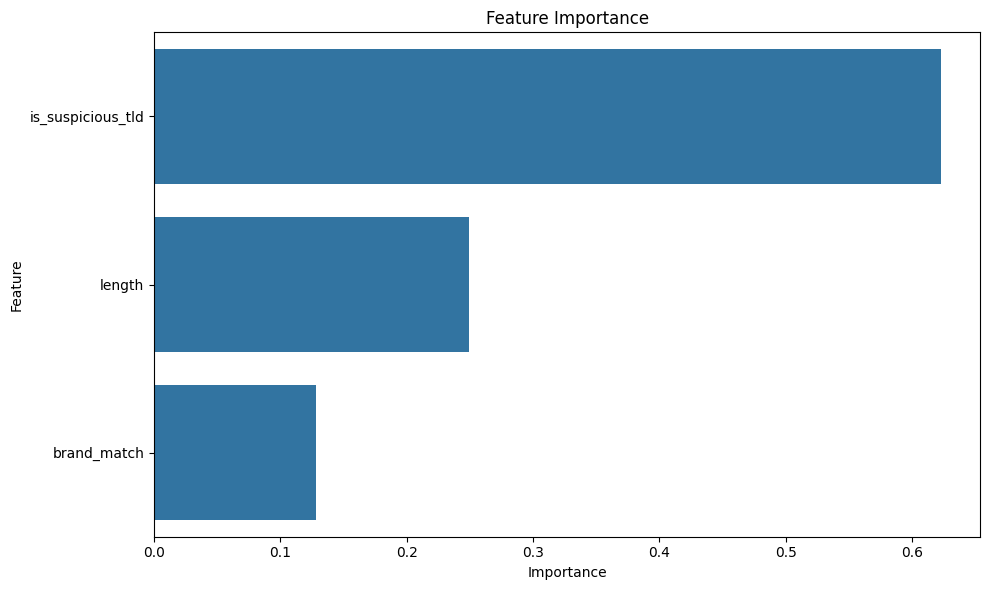

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Visualize Feature Importance

This cell generates a bar plot to visually represent the feature importance derived from the trained XGBoost model. This helps in understanding the model's decision-making process and confirming the impact of feature engineering and sample weighting on feature prioritization.